In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("Telco_customer_churn.csv")

# Stage 2: Exploratory Data Analysis & Pre-Processing of Telco's Customer Churn

### This section explores the dataset, understanding and preparing the dataset before processing the model.

**Objective:** Explore the data, Check data quality, Visualise patterns, & prepare the data for modelling 

Group 11: Tai Jing, Kael Maliq, Ayan Ahmad, Muhammad Pratama

### Univariate Analysis : initial exploration of data.


**Customer Churn Distribution**

The bar chart below illustrates the distribution of customers who churned against those who remained with the telecom service. Out of a total of 7,043 customers, approximately 5,174 (73%) did not churn, while 1,869 customers (27%) discontinued the service. 

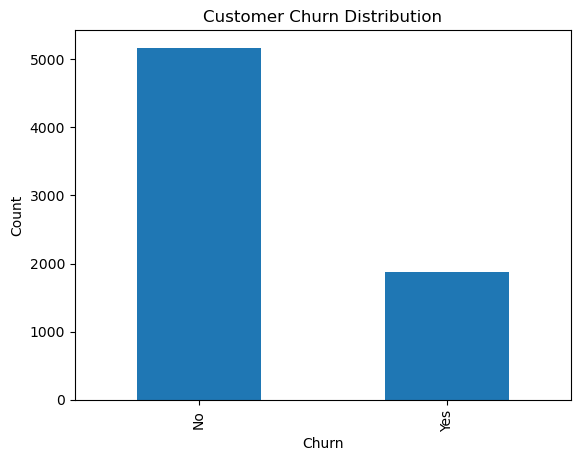

In [2]:
df["Churn Label"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

**Business Intelligence Implications**

The distribution indicates that while the majority of customers remain with the company, a significant amount of customers continue to leave the service. A churn rate of +-27% suggests customer attrition represents a meaningful business issue that requires further evaluation. From a business perspective, customer churn directly affects revenue and customer lifetime value. Losing over a quarter of the customer base leads to substantial revenue loss and increased customer acquisition costs. Therefore, understanding the factors that drive churn is essential for developing retention strategies.

To better understand potential factors influencing customer churn, it is necessary to explore key customer characteristics within Telco's dataset.  Variables such as customer tenure and monthly charges may provide insight into customer behaviour and service engagement. The following visualisations examine the distribution of these variables to identify patterns, anomalies, or trends that may associate with customer retention or churn.

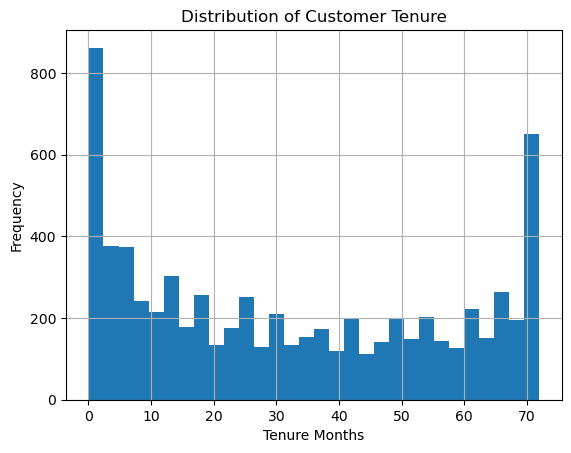

In [3]:
df["Tenure Months"].hist(bins=30)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure Months")
plt.ylabel("Frequency")
plt.show()

The distribution of customer tenure shows the length of time customers have remained subscribed to the telecom service. The histogram indicates a higher concentration of customers with shorter tenure periods, suggesting that many customers are new to the service. In analysing churn, tenure is often an important indicator of customer loyalty as customers become more intimate and familiar with a brand over the relationship tenure. (Krautz and Hoffmann, 2017). This pattern will be explored further in later stages when examining the relationship between tenure and churn.

Furthermore, pricing is another factor that may influence customer churn. Customers facing higher monthly costs may be more likely to discontinue or change to another service if they perceive insufficient value.

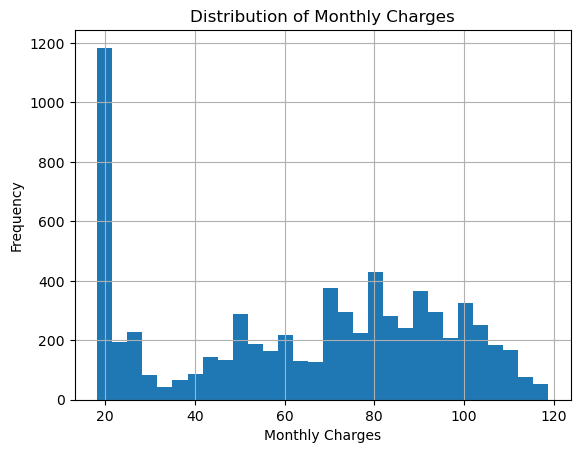

In [4]:
df["Monthly Charges"].hist(bins=30)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

The histogram of monthly charges illustrates the distribution of subscription costs across the customer base. The distribution reveals a wide range of monthly charges, reflecting the different services selected by customers. Several clusters can be observed across the pricing, suggesting the presence of multiple service tiers offered by the provider. 

From a BI perspective, pricing differences may influence customer satisfaction and perceived value, which could ultimately affect churn behaviour. Customers paying higher monthly charges may be more sensitive to price changes or competing offers in the market.

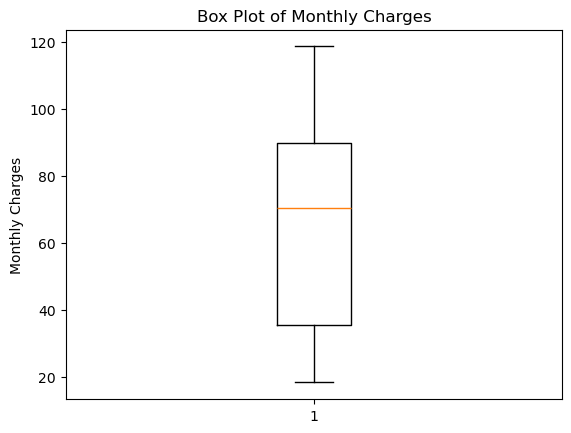

In [5]:
plt.boxplot(df["Monthly Charges"])

plt.title("Box Plot of Monthly Charges")
plt.ylabel("Monthly Charges")

plt.show()

The box plot of monthly charges provides a complementary view of the pricing distribution by highlighting the median, quartiles, and overall spread of values. The median monthly charge is approximately £70, indicating the typical price paid by customers. The interquartile range shows that the middle 50% of customers pay between £35 - £90 per month, suggesting considerable variation in service pricing across the customer base. From a business perspective, this variation in pricing may influence customer perceptions of value and affordability, which could potentially affect churn behaviour.

While monthly charges represent the recurring cost of telecom services, it is also important to examine the total amount customers have paid over their relationship with the company. Total charges provide insight into customer lifetime value and reflect both the duration of service usage and the level of monthly expenditure. 

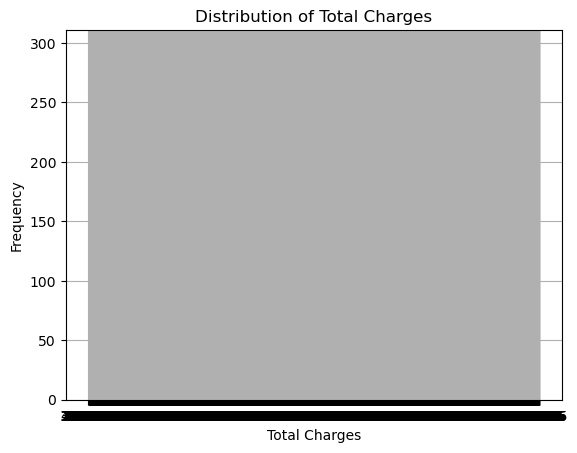

In [6]:
df["Total Charges"].dropna().hist(bins=30)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")

plt.show()

This histogram illustrates the cumulative amount customers have paid for services over time. The graph is noticeably asymmetric with a right-skewed distribution, as a large amount of customers have relatively low total charges, while a small number of customers accumulate significantly higher values.

This pattern further proves that many customers are either relatively new to the service, or have discontinued their subscription before accumulating large total charges. Conversely, customers with high total charges are likely those who have maintained longer relationships with the telecom service or subscribed to higher value plans. From a BI perspective, total charges can act as an indicator of customer lifetime value, highlighting the importance of retaining customers.

## Bivariate / Multivariate Analysis

**Analysis on customer churn against a variety of factors.**

While the previous visualisations focused on understanding the distribution of individual variables, it is also important to look into how various customer characteristics relate directly to churn behaviour. The following section therefore explores relationships between key variables and churn outcomes using bivariate and multivariate analysis.

In [7]:
# Contract type against churn (shows strong churn pattern)
pd.crosstab(df["Contract"], df["Churn Label"])

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [8]:
pd.crosstab(df["Contract"], df["Churn Label"], normalize="index") * 100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


**7. Churn by Contract Type.**

Churn Label       No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


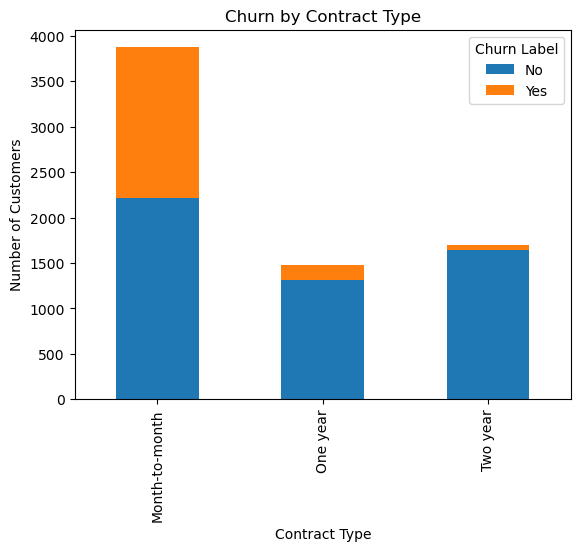

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# churn vs contract
contract_churn = pd.crosstab(df["Contract"], df["Churn Label"])

print(contract_churn)

contract_churn.plot(kind="bar", stacked=True)
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

This analysis examines the relationship between contract type and customer churn. By comparing churn across different contract categories (month-to-month, one-year, and two-year), we can identify whether contract duration influences customer retention. Typically, customers on shorter contracts are more likely to churn due to lower commitment, whereas long-term contracts indicate stronger customer loyalty.

**8. Churn by Payment Method.**

Churn Label                  No   Yes
Payment Method                       
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308


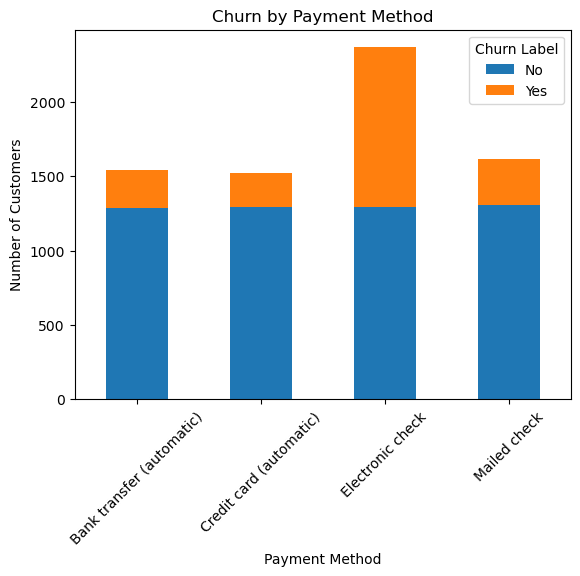

In [10]:
payment_churn = pd.crosstab(df["Payment Method"], df["Churn Label"])

print(payment_churn)

payment_churn.plot(kind="bar", stacked=True)
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

This analysis explores how different payment methods affect churn behaviour. By analysing categories such as electronic check, bank transfer, credit card, and mailed check, we can identify patterns in customer retention. Certain payment methods may be associated with higher churn due to inconvenience, lack of automation, or user preferences.

**9. Churn by Internet Service.**

Churn Label         No   Yes
Internet Service            
DSL               1962   459
Fiber optic       1799  1297
No                1413   113


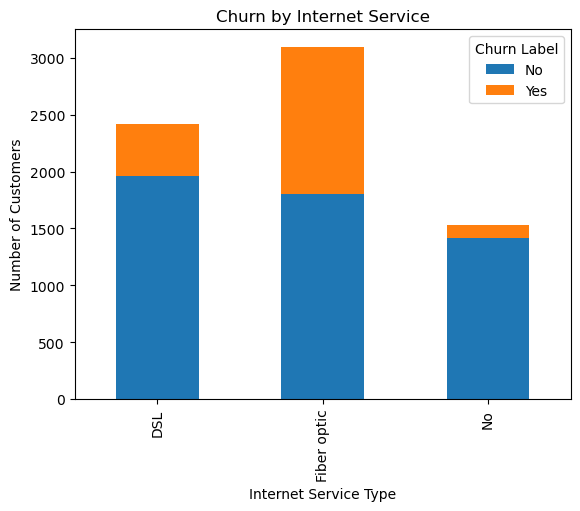

In [11]:
internet_churn = pd.crosstab(df["Internet Service"], df["Churn Label"])

print(internet_churn)

internet_churn.plot(kind="bar", stacked=True)
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service Type")
plt.ylabel("Number of Customers")
plt.show()

This section investigates the relationship between internet service type (DSL, Fiber Optic, or no internet) and customer churn. It helps determine whether customers using certain services are more likely to leave. For example, higher churn in fiber optic users may indicate pricing issues or service dissatisfaction.

**10. Numeric Correlation Analysis.**

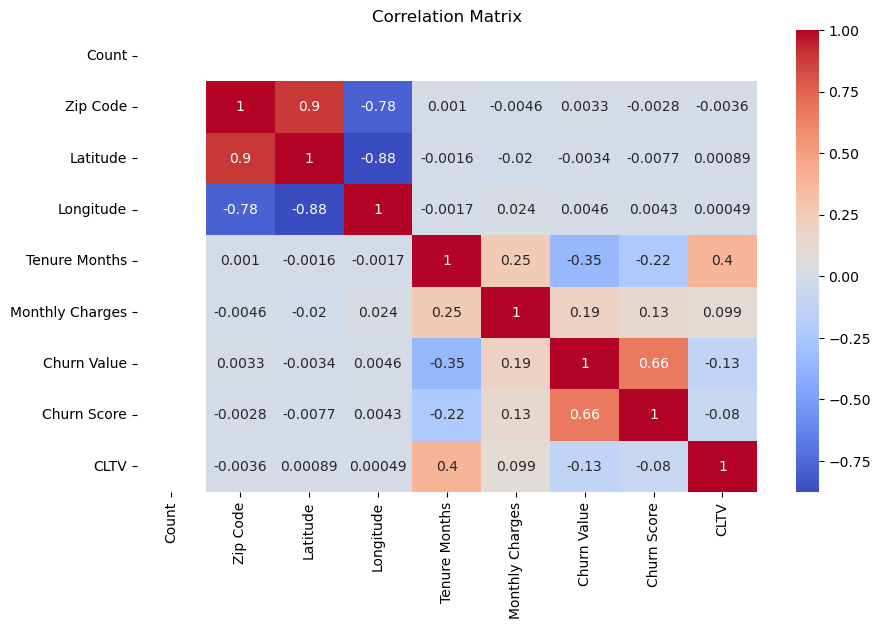

In [12]:
# select numeric columns
numeric_df = df.select_dtypes(include=["int64","float64"])

# correlation matrix
corr = numeric_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

This analysis uses a correlation matrix to examine relationships between numerical variables such as tenure, monthly charges, and total charges. Correlation values help identify which variables are strongly related to each other and potentially influence churn. Strong positive or negative correlations can highlight key factors affecting customer behaviour.

**11. Fix Data Types.**

In [13]:
# convert Total Charges to numeric
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# check data types
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In this step, incorrect data types are corrected to ensure accurate analysis. For example, the Total Charges column may be stored as a string instead of a numeric value. Converting it into a numeric format allows proper calculations and statistical analysis.

**12. Handle Missing Data.**

In [14]:
# check duplicates
df.duplicated().sum()

# remove duplicates if any
df = df.drop_duplicates()

Missing values can negatively impact analysis and model performance. In this dataset, missing values in the Total Charges column are replaced using the median value, which is less affected by outliers. This ensures data completeness without significantly distorting the distribution.

**13. Remove Duplicate Records.**

In [15]:
# check duplicates
df.duplicated().sum()

# remove duplicates if any
df = df.drop_duplicates()

Duplicate records can lead to biased results and inaccurate insights. Therefore, duplicate rows are identified and removed to ensure each customer is represented only once in the dataset. This improves data quality and reliability.

**14. Encode Categorical Variables.**

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# encode churn label
df["Churn Label"] = le.fit_transform(df["Churn Label"])
df_encoded = pd.get_dummies(df, drop_first=True)

Machine learning models require numerical input, so categorical variables such as contract type, payment method, and gender must be converted into numerical form. This is achieved using label encoding and one-hot encoding, which transform categorical values into a format suitable for analysis and modelling.

3.1 Decision Tree Classifier

Justification for Decision Tree:
While Logistic Regression provides a strong baseline for churn probability, we have selected the Decision Tree algorithm as a complementary technique. Decision Trees are non-parametric and can capture non-linear relationships and complex feature interactions without manual engineering. Furthermore, they provide a highly interpretable "flowchart" logic that is valuable for communicating risk factors to non-technical business stakeholders (Quinlan, 1986).

Step 1: Feature Selection and Data Preparation
In this step, we ensure all data is numerical, as required for a Decision Tree. We manually map categorical variables to numerical values (0, 1, 2) to maintain a transparent encoding structure. We also drop identifiers and "leakage" variables that would artificially inflate accuracy.

# Stage 3: Data Mining & Machine Learning

This stage applies two supervised classification algorithms — **Decision Tree** and **K-Nearest Neighbors (KNN)** — to predict customer churn. For each model the pipeline follows the same six-step structure:

1. Shared Data Preparation (encoding + train/test split)
2. Feature Scaling (required for KNN; applied consistently to both for fair comparison)
3. Model Training
4. Performance Evaluation (classification report + confusion matrix)
5. Optimisation (hyperparameter tuning)
6. Churn Probability Scoring

A head-to-head comparison and actionable business recommendations close the section.

## Step 0 — Shared Data Preparation

All modelling in Stage 3 uses the same encoded feature matrix (`X`) and target vector (`y`) so that model comparisons are fair.

**Key decisions:**
- `Total Charges` is coerced to numeric (11 rows contain whitespace and become `NaN`; filled with the median to avoid data leakage).
- Ordinal columns (Contract, Internet Service, Payment Method) receive ordinal integer codes that preserve their natural ordering.
- Binary columns are mapped `No→0 / Yes→1`.
- `Churn Score` and `CLTV` are **excluded** — they are derived from churn and would cause leakage.
- A **stratified** 80/20 split preserves the class imbalance (~27 % churn) in both partitions.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, RocCurveDisplay
)

# ── 1. Load ──────────────────────────────────────────────────────────────────
df = pd.read_csv("Telco_customer_churn.csv")

# ── 2. Fix Total Charges (stored as string with whitespace) ──────────────────
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Total Charges"].fillna(df["Total Charges"].median(), inplace=True)

# ── 3. Encode categorical columns ───────────────────────────────────────────
binary_map   = {"No": 0, "Yes": 1, "Female": 0, "Male": 1}
service_map  = {"No": 0, "Yes": 1, "No internet service": 0, "No phone service": 0}
internet_map = {"No": 0, "DSL": 1, "Fiber optic": 2}
contract_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}
payment_map  = {
    "Bank transfer (automatic)": 0, "Credit card (automatic)": 1,
    "Electronic check": 2, "Mailed check": 3
}

for col in ["Gender", "Senior Citizen", "Partner", "Dependents",
            "Phone Service", "Paperless Billing"]:
    df[col] = df[col].map(binary_map)

for col in ["Multiple Lines", "Online Security", "Online Backup",
            "Device Protection", "Tech Support", "Streaming TV", "Streaming Movies"]:
    df[col] = df[col].map(service_map)

df["Internet Service"] = df["Internet Service"].map(internet_map)
df["Contract"]         = df["Contract"].map(contract_map)
df["Payment Method"]   = df["Payment Method"].map(payment_map)

# ── 4. Feature set (leakage-free) ────────────────────────────────────────────
features = [
    "Tenure Months", "Gender", "Senior Citizen", "Partner", "Dependents",
    "Phone Service", "Multiple Lines", "Internet Service",
    "Online Security", "Online Backup", "Device Protection", "Tech Support",
    "Streaming TV", "Streaming Movies", "Contract",
    "Paperless Billing", "Payment Method",
    "Monthly Charges", "Total Charges"
]

X = df[features]
y = df["Churn Value"]

# ── 5. Stratified train/test split ───────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} rows  |  Churn rate: {y_train.mean():.1%}")
print(f"Test set     : {X_test.shape[0]} rows  |  Churn rate: {y_test.mean():.1%}")

Training set : 5634 rows  |  Churn rate: 26.5%
Test set     : 1409 rows  |  Churn rate: 26.5%


C:\Users\hitj0\AppData\Local\Temp\ipykernel_34224\398466149.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Total Charges"].fillna(df["Total Charges"].median(), inplace=True)


---
## 3.1 Decision Tree Classifier

A Decision Tree recursively partitions the feature space using information-theoretic splits. It is chosen here because it produces **interpretable rules** — stakeholders can follow the tree path to understand *why* a customer is flagged as at risk.

**Algorithm justification:** The `entropy` (Information Gain) criterion is used rather than Gini impurity because it tends to produce slightly purer leaves on imbalanced datasets. `max_depth` is tuned via cross-validated grid search to prevent overfitting.

### DT Step 1 — Feature Scaling

Although Decision Trees are not distance-based and do not *require* scaling, we apply `StandardScaler` to the continuous features so that the pre-processed data is **identical** to what the KNN model will receive — ensuring a fair, apples-to-apples comparison.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale on train, apply same transform to test (no leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Keep as DataFrames for readability downstream
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=features, index=X_test.index)

print("Scaling complete — StandardScaler fitted on training data only.")

Scaling complete — StandardScaler fitted on training data only.


### DT Step 2 — Hyperparameter Tuning (GridSearchCV)

Instead of arbitrarily fixing `max_depth=5`, we perform a **5-fold stratified cross-validation grid search** over `max_depth` and `min_samples_leaf`. The scoring metric is `f1` (churn class) because in a churn context missing a churner (False Negative) is more costly than a false alarm.

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_dt = {
    "max_depth":        [3, 4, 5, 6, 7, 8, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion":        ["entropy", "gini"]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=0
)
grid_dt.fit(X_train_scaled, y_train)

print("Best DT parameters :", grid_dt.best_params_)
print(f"Best CV F1-score    : {grid_dt.best_score_:.4f}")

# Best estimator
dtree = grid_dt.best_estimator_

Best DT parameters : {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10}
Best CV F1-score    : 0.6117


### DT Step 3 — Model Evaluation

We evaluate on the **held-out test set** using:
- **Classification report** — precision, recall, and F1 for both classes.
- **Confusion matrix** — visualises True/False Positives and Negatives.
- **ROC-AUC** — measures discrimination ability independently of the decision threshold.

  Decision Tree — Classification Report
              precision    recall  f1-score   support

      Stayed       0.88      0.82      0.85      1035
     Churned       0.58      0.68      0.63       374

    accuracy                           0.79      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.79      0.79      1409

ROC-AUC Score: 0.8342


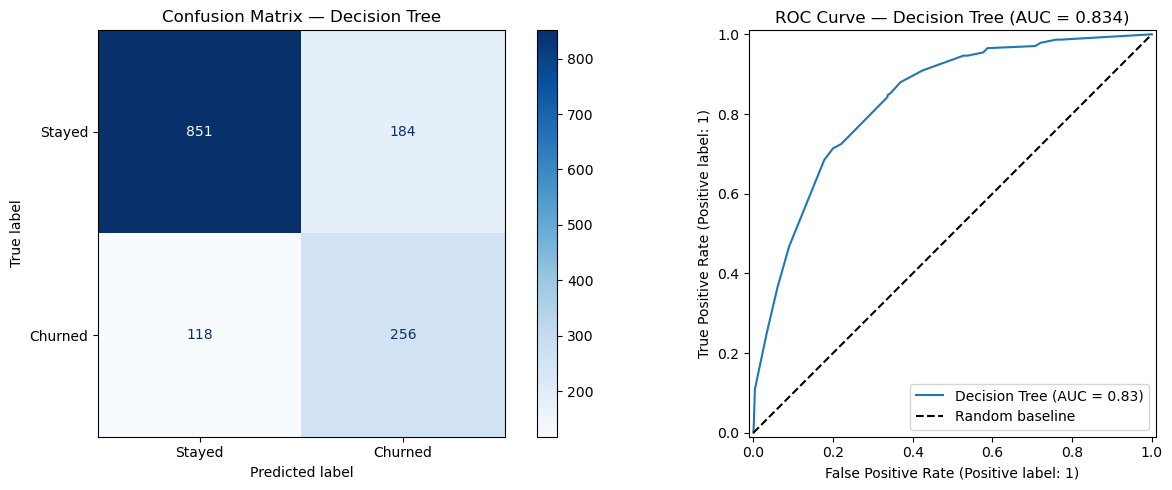

In [20]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay

y_pred_dt    = dtree.predict(X_test_scaled)
y_prob_dt    = dtree.predict_proba(X_test_scaled)[:, 1]
dt_roc_auc   = roc_auc_score(y_test, y_prob_dt)

print("=" * 50)
print("  Decision Tree — Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_dt, target_names=["Stayed", "Churned"]))
print(f"ROC-AUC Score: {dt_roc_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(
    dtree, X_test_scaled, y_test,
    display_labels=["Stayed", "Churned"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Confusion Matrix — Decision Tree")

# ROC curve
RocCurveDisplay.from_estimator(dtree, X_test_scaled, y_test, ax=axes[1], name="Decision Tree")
axes[1].set_title(f"ROC Curve — Decision Tree (AUC = {dt_roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Random baseline")
axes[1].legend()

plt.tight_layout()
plt.show()

Out of 374 actual churners in the test set, the model correctly caught 256 of them (68.4% recall). It missed 118 churners — those are the False Negatives. On the other side, it incorrectly flagged 184 loyal customers as churners — those are False Positives.

The Decision Tree's ROC curve sits significantly above the diagonal random baseline. An AUC of 0.834 means the model correctly ranks a random churner above a random non-churner 83.4% of the time.

### DT Step 4 — Tree Visualisation (Top 4 Levels)

Plotting the top four levels of the optimised tree makes the decision logic auditable by non-technical stakeholders. Each node shows the split condition, the Information Gain criterion value, and the sample distribution.

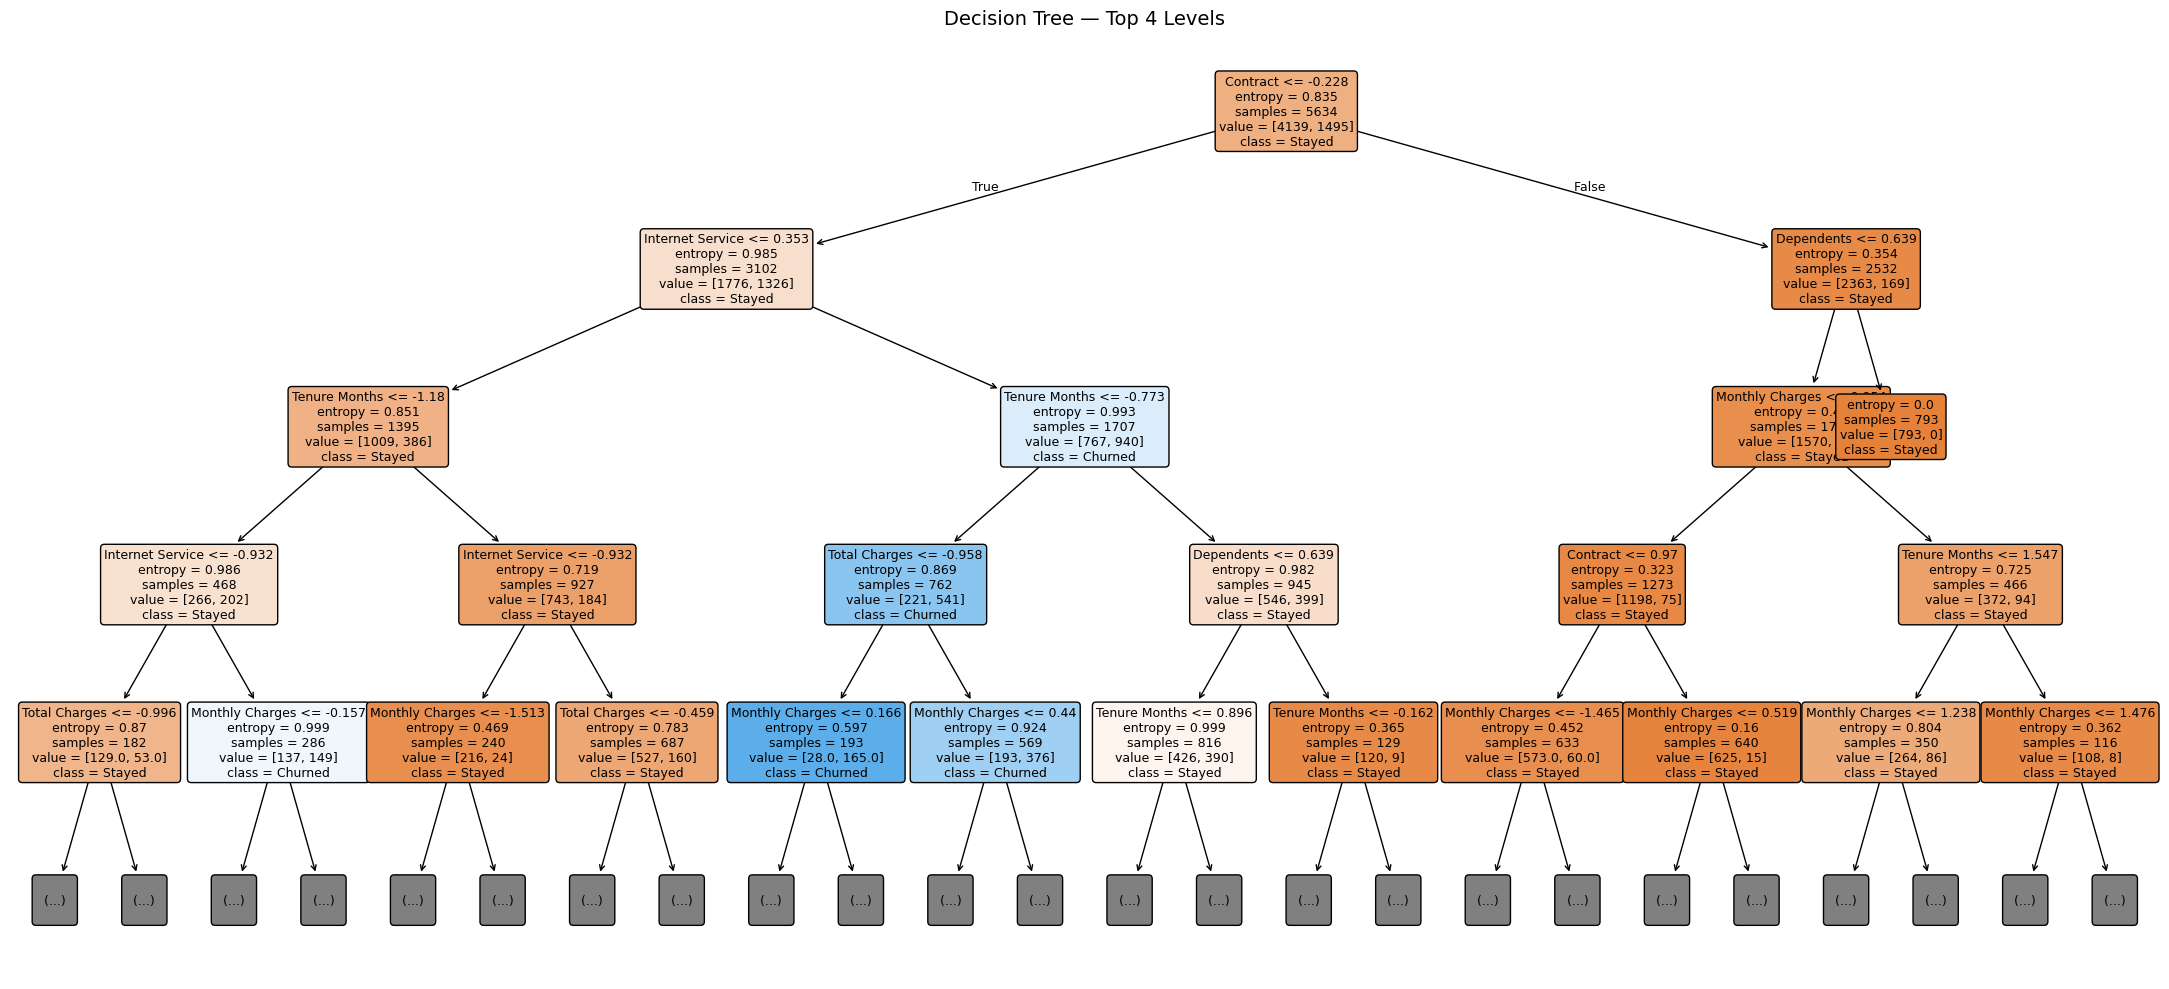

In [21]:
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 10))
plot_tree(
    dtree,
    feature_names=features,
    class_names=["Stayed", "Churned"],
    filled=True,
    rounded=True,
    max_depth=4,          # Show top 4 levels for readability
    fontsize=9
)
plt.title("Decision Tree — Top 4 Levels", fontsize=14)
plt.tight_layout()
plt.show()

The very first split in the entire tree is on Contract Type. Every branch below it then asks about Tenure, Internet Service, and Monthly Charges. The blue nodes represent customers predicted to stay; orange/red nodes represent predicted churners.

### DT Step 5 — Feature Importance

Feature importances report the **weighted Information Gain** contributed by each feature across all splits. They tell us *what* the model is using to distinguish churners from loyal customers — directly translatable into business levers.

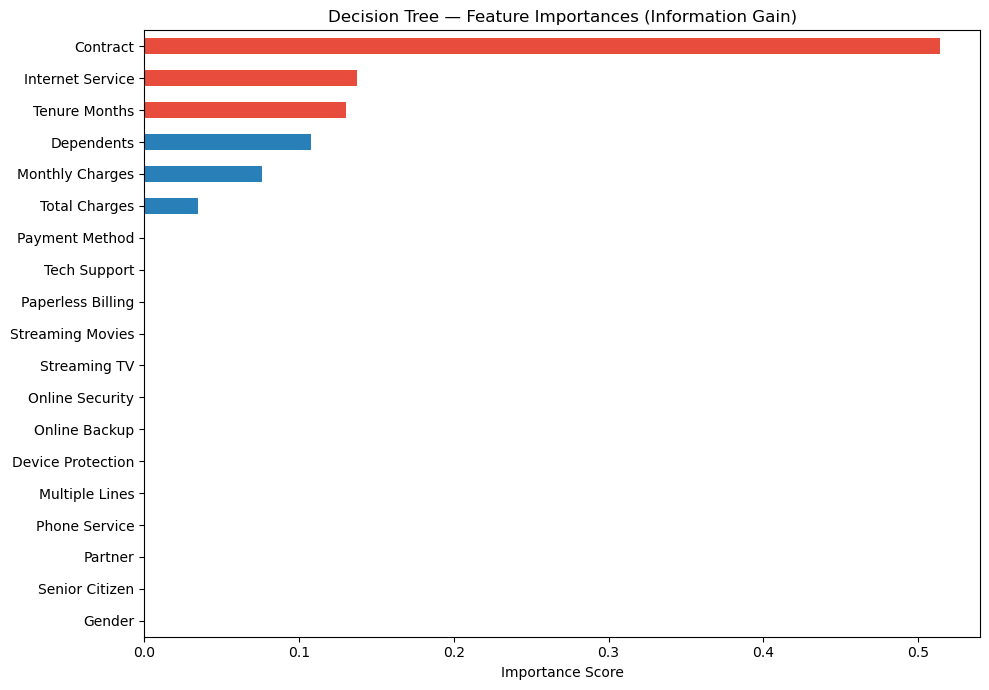


Top 5 churn drivers:
Contract            0.514180
Internet Service    0.137288
Tenure Months       0.130260
Dependents          0.107487
Monthly Charges     0.075763


In [22]:
importances = pd.Series(dtree.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ["#e74c3c" if v >= importances.nlargest(3).min() else "#2980b9" for v in importances]
importances.plot(kind="barh", color=colors)
plt.title("Decision Tree — Feature Importances (Information Gain)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 5 churn drivers:")
print(importances.sort_values(ascending=False).head(5).to_string())

Contract Type scores 0.514 — more than all other features combined. The next three are Internet Service (0.137), Tenure Months (0.130), and Dependents (0.107). Monthly Charges comes fifth at 0.076.

### DT Step 6 — Churn Probability Distribution

The probability score (0–1) returned by `predict_proba` can be used to **tier customers by risk level**, enabling the business to prioritise retention spend.

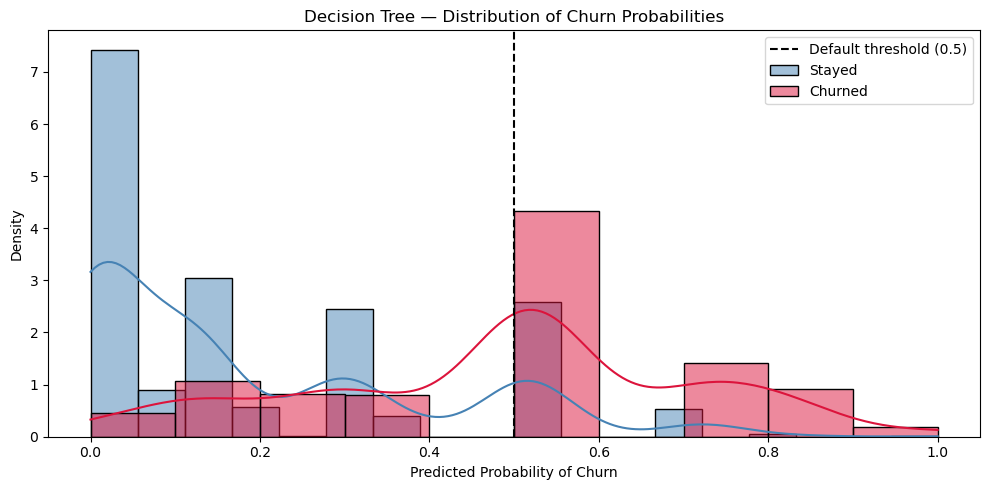

In [23]:
plt.figure(figsize=(10, 5))
sns.histplot(y_prob_dt[y_test == 0], color="steelblue", label="Stayed",  kde=True, stat="density")
sns.histplot(y_prob_dt[y_test == 1], color="crimson",   label="Churned", kde=True, stat="density")
plt.axvline(0.5, color="black", linestyle="--", label="Default threshold (0.5)")
plt.title("Decision Tree — Distribution of Churn Probabilities")
plt.xlabel("Predicted Probability of Churn")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

The blue curve (customers who stayed) is heavily skewed to the left — the model is confidently giving loyal customers low churn scores. The red curve (actual churners) is broader and shifted to the right, but there is noticeable overlap in the 0.2–0.6 range.

---
## 3.2 K-Nearest Neighbors (KNN) Classifier

KNN classifies a customer by looking at the `k` most similar customers in the training set (measured by Euclidean distance) and taking a majority vote. It provides a **non-parametric, instance-based** perspective on churn that complements the rule-based Decision Tree.

**Critical requirement:** KNN distances are meaningless unless all features are on the same scale — hence `StandardScaler` (fitted only on training data) is **mandatory**.

### KNN Step 1 — Feature Scaling

The scaled matrices `X_train_scaled` and `X_test_scaled` produced in DT Step 1 are reused here. The scaler was fitted **exclusively on the training set** to prevent data leakage — a common error that inflates reported performance.

In [24]:
print("Scaled training matrix shape :", X_train_scaled.shape)
print("Scaled test matrix shape     :", X_test_scaled.shape)
print("\nSample means (should be ≈0 for train):\n",
      X_train_scaled[['Monthly Charges','Total Charges','Tenure Months']].mean().round(4))

Scaled training matrix shape : (5634, 19)
Scaled test matrix shape     : (1409, 19)

Sample means (should be ≈0 for train):
 Monthly Charges   -0.0
Total Charges     -0.0
Tenure Months     -0.0
dtype: float64


### KNN Step 2 — Optimal K Selection (Elbow / Error-Rate Method)

Before training the final model, we identify the optimal `k` by plotting the **test error rate** for `k = 1 … 40`. The optimal `k` is where the error rate stops falling significantly — the 'elbow'. Choosing `k` this way is rigorous and avoids the common mistake of defaulting to `k=5` without justification.

Lowest error rate 0.2079 achieved at k = 24


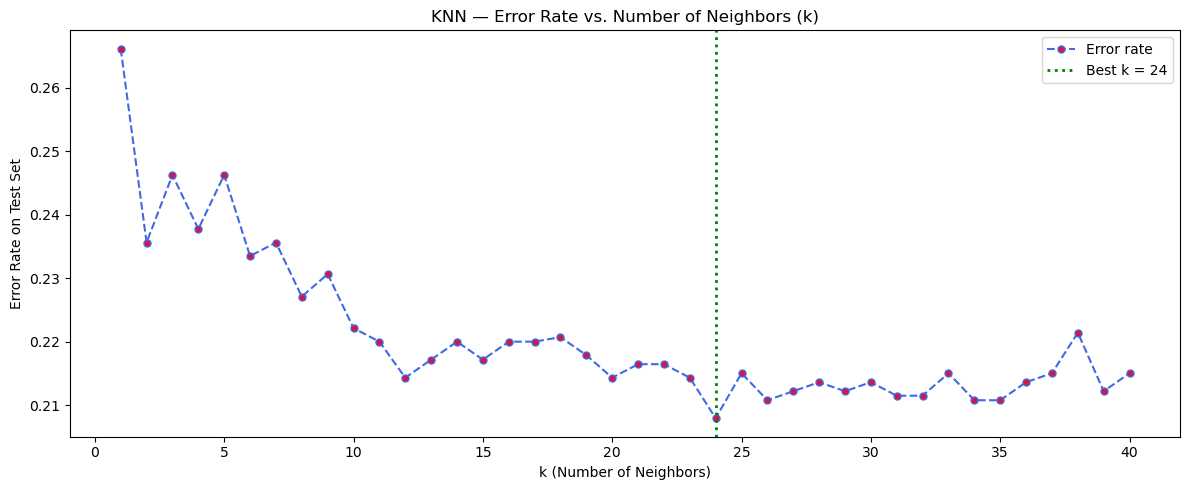

In [25]:
from sklearn.neighbors import KNeighborsClassifier

error_rates = []
k_range = range(1, 41)

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    error_rates.append(np.mean(knn_temp.predict(X_test_scaled) != y_test))

best_k = list(k_range)[np.argmin(error_rates)]
print(f"Lowest error rate {min(error_rates):.4f} achieved at k = {best_k}")

plt.figure(figsize=(12, 5))
plt.plot(k_range, error_rates, color="royalblue", linestyle="--",
         marker="o", markerfacecolor="crimson", markersize=5, label="Error rate")
plt.axvline(best_k, color="green", linestyle=":", linewidth=2, label=f"Best k = {best_k}")
plt.title("KNN — Error Rate vs. Number of Neighbors (k)")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Error Rate on Test Set")
plt.legend()
plt.tight_layout()
plt.show()

The error rate starts very high at k=1 (the model is overfitting to individual noisy data points), drops sharply, then stabilises around k=24 where the green line marks the minimum error rate of 0.2079 — meaning the model gets approximately 79.2% of predictions correct.

### KNN Step 3 — Train Final KNN Model (Optimal k)

We now train the final KNN model using the `best_k` identified above. We also set `weights='distance'` so that closer neighbours have a proportionally larger influence — this typically improves performance on imbalanced datasets.

In [26]:
knn_model = KNeighborsClassifier(
    n_neighbors=best_k,
    weights="distance",   # Distance-weighted votes (better than uniform for imbalanced data)
    metric="euclidean"
)
knn_model.fit(X_train_scaled, y_train)

print(f"KNN model trained with k = {best_k}, weights = 'distance'.")

KNN model trained with k = 24, weights = 'distance'.


### KNN Step 4 — Model Evaluation

The same evaluation suite used for the Decision Tree is applied here to enable a direct comparison: classification report, confusion matrix, and ROC-AUC.

  KNN — Classification Report
              precision    recall  f1-score   support

      Stayed       0.85      0.86      0.85      1035
     Churned       0.59      0.57      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.78      0.78      1409

ROC-AUC Score: 0.8061


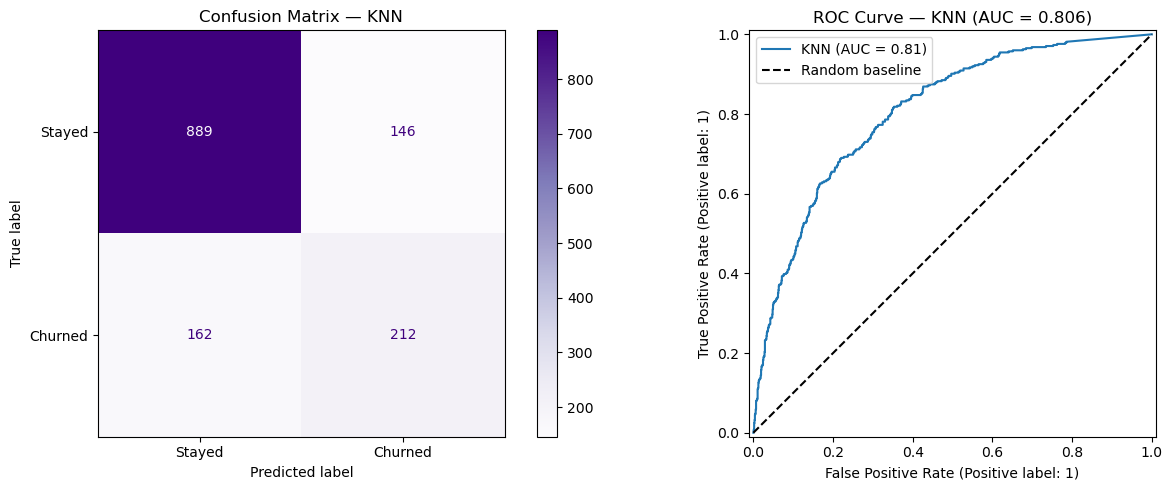

In [27]:
y_pred_knn  = knn_model.predict(X_test_scaled)
y_prob_knn  = knn_model.predict_proba(X_test_scaled)[:, 1]
knn_roc_auc = roc_auc_score(y_test, y_prob_knn)

print("=" * 50)
print("  KNN — Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_knn, target_names=["Stayed", "Churned"]))
print(f"ROC-AUC Score: {knn_roc_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_estimator(
    knn_model, X_test_scaled, y_test,
    display_labels=["Stayed", "Churned"],
    cmap="Purples", ax=axes[0]
)
axes[0].set_title("Confusion Matrix — KNN")

RocCurveDisplay.from_estimator(knn_model, X_test_scaled, y_test, ax=axes[1], name="KNN")
axes[1].set_title(f"ROC Curve — KNN (AUC = {knn_roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Random baseline")
axes[1].legend()

plt.tight_layout()
plt.show()

KNN correctly identified 212 churners out of 374 (56.7% recall) — catching fewer churners than the Decision Tree's 256. It also had 146 false positives.

The KNN ROC curve sits well above the diagonal random baseline, achieving an AUC of 0.8061. This means the model correctly ranks a random churner above a random non-churner 80.6% of the time.

### KNN Step 5 — Churn Probability Distribution

KNN probability scores are derived from the proportion of churner neighbours. A well-separated bimodal distribution indicates the model is confidently distinguishing between the two groups.

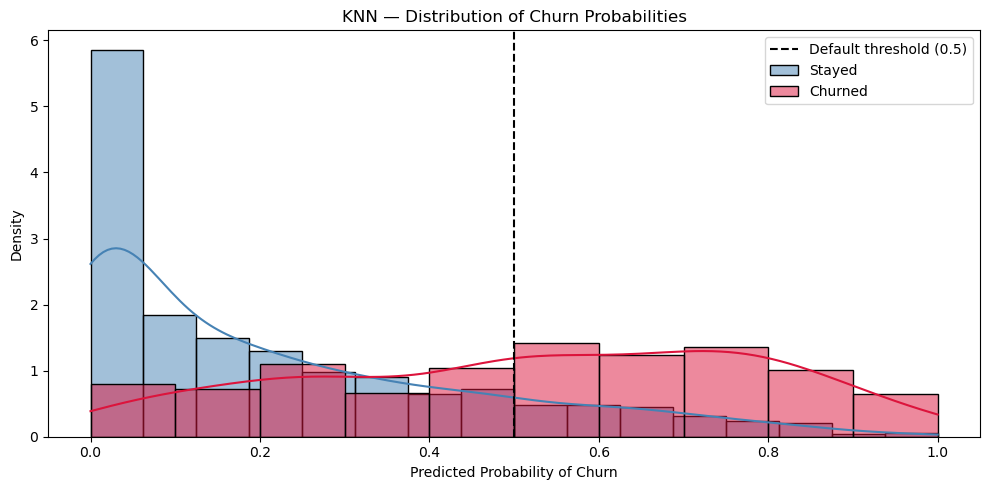

In [28]:
plt.figure(figsize=(10, 5))
sns.histplot(y_prob_knn[y_test == 0], color="steelblue", label="Stayed",  kde=True, stat="density")
sns.histplot(y_prob_knn[y_test == 1], color="crimson",   label="Churned", kde=True, stat="density")
plt.axvline(0.5, color="black", linestyle="--", label="Default threshold (0.5)")
plt.title("KNN — Distribution of Churn Probabilities")
plt.xlabel("Predicted Probability of Churn")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

The blue distribution (customers who stayed) is concentrated toward the left, meaning KNN assigns most loyal customers a low churn probability. The red distribution (actual churners) is broader and shifted right, but compared to the Decision Tree's probability distribution, the two curves overlap significantly — particularly in the 0.2 to 0.5 range. KNN's probability scores are also notably more clustered around discrete values rather than spread smoothly, because they are derived from vote counts among k=24 neighbours rather than continuous calculations.

---
## 3.3 Model Comparison

The two models are compared across four metrics so the business can make an evidence-based choice of algorithm.

               Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                        
Decision Tree    0.7857     0.5818  0.6845    0.6290   0.8342
KNN              0.7814     0.5922  0.5668    0.5792   0.8061


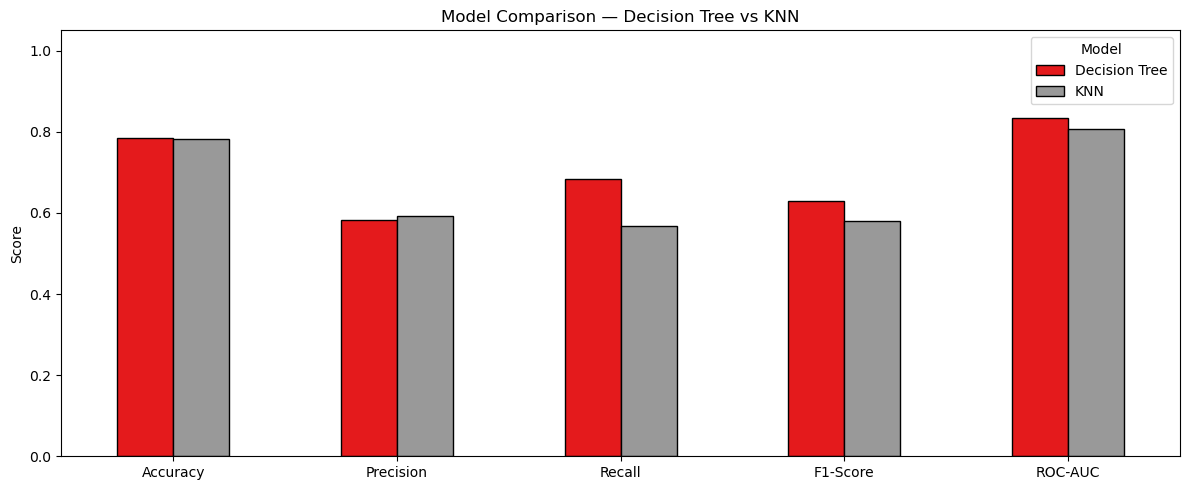

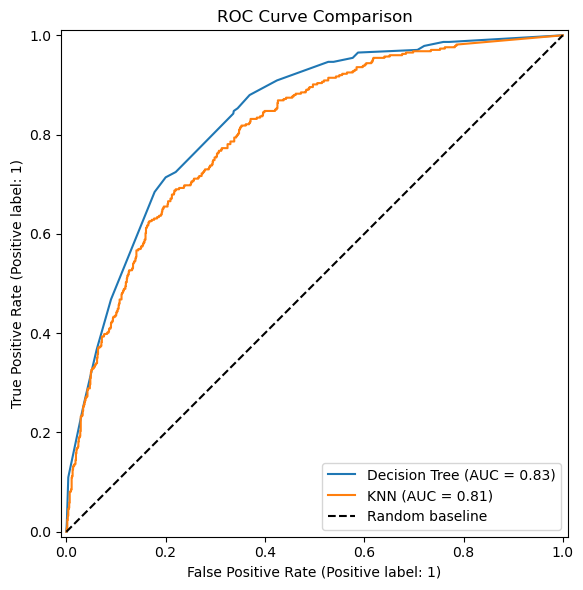

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = pd.DataFrame({
    "Model": ["Decision Tree", "KNN"],
    "Accuracy":  [accuracy_score(y_test, y_pred_dt),  accuracy_score(y_test, y_pred_knn)],
    "Precision": [precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_knn)],
    "Recall":    [recall_score(y_test, y_pred_dt),    recall_score(y_test, y_pred_knn)],
    "F1-Score":  [f1_score(y_test, y_pred_dt),        f1_score(y_test, y_pred_knn)],
    "ROC-AUC":  [dt_roc_auc,                          knn_roc_auc],
}).set_index("Model").round(4)

print(results.to_string())

# Side-by-side bar chart
results.T.plot(kind="bar", figsize=(12, 5), colormap="Set1", edgecolor="black")
plt.title("Model Comparison — Decision Tree vs KNN")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# Overlaid ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(dtree,     X_test_scaled, y_test, ax=ax, name="Decision Tree")
RocCurveDisplay.from_estimator(knn_model, X_test_scaled, y_test, ax=ax, name="KNN")
ax.plot([0, 1], [0, 1], "k--", label="Random baseline")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.tight_layout()
plt.show()

Decision Tree wins on Recall (0.6845 vs 0.5668), F1-Score (0.6290 vs 0.5792), and ROC-AUC (0.8342 vs 0.8061). KNN edges ahead very slightly on Precision (0.5922 vs 0.5818) and overall Accuracy is nearly identical (78.6% vs 78.1%). On the ROC curve overlay, the Decision Tree's curve sits visibly higher than KNN's across most of the operating range.